This is the screenshot of the plan and the resulting line dose in RayStation.
I created an ROI of water material in a region where there were no cell flasks I set a field to cover the entire phantom from the bottom. Energy set to 69.4 MeV with a 2 cm range shifter selected.
I took the line dose along the central axis and exported. 

![alt text](<../Line dose analysis/RayStation screenshot.png>)

In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

In [39]:
#The data requires some preprocessing since RS adds a bunch of stuff at the beginning. Also the file is ; delimited.
#So here I read in the file and convert it to a dataframe with columns x,y,z,dose
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Line dose analysis\Line dose CellFlask 26 Sep 2025_edited.xlsx"
data = pd.read_excel(path)
data = data['#X [cm];Y [cm];Z [cm];Dose [Gy (RBE)]'].str.split(';')
data = data[0:-1]

df = pd.DataFrame(columns=['X', 'Y', 'Z', 'Dose'])
for i in range(len(data)):
    df.loc[len(df)] = data[i]

print(df.head())

        X         Y       Z    Dose
0  -0.072   -22.500   7.670   0.021
1  -0.072   -22.500   7.671   0.021
2  -0.072   -22.500   7.672   0.021
3  -0.072   -22.500   7.673   0.021
4  -0.072   -22.500   7.674   0.021


In [ ]:
#Check that line profile has single x and y values --> validate that it is perfectly straight along CAX
print(df['X'].unique())
print(df['Y'].unique())

['-0.072']
[' -22.500']


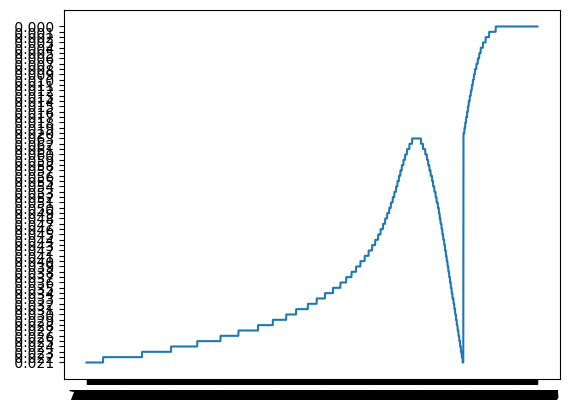

In [ ]:
#Plot line dose as function of depth
plt.plot(df['Z'], df['Dose'])

#Bit weird, check next week